# 🧥 ARVTON — AR/VR Virtual Try-On · Full Training Notebook

> **Run this notebook top-to-bottom on Google Colab (T4 free tier or A100 Pro)**
## What this notebook does
| Step | Description | Est. Time |
|------|-------------|----------|
| 1 | GPU check + environment setup | ~3 min |
| 2 | Clone repo + install dependencies | ~4 min |
| 3 | Mount Google Drive | 1 min |
| 4 | Prepare dataset (synthetic or custom) | ~5-15 min |
| 5 | Configure training hyperparameters | instant |
| 6 | **Train GAN model** | ~240 min (4 hrs) |
| 7 | Plot loss curves + evaluate | ~2 min |
| 8 | Save checkpoints to Drive + download | ~1 min |
---
### Architecture Overview
```
Person Photo + Garment Image
        │
     [SAM 2] → Segmentation masks
  [Leffa / CatVTON] → 2D try-on composite
  [HMR 2.0 + ECON] → SMPL mesh
  [TripoSR / SyncHuman] → .glb 3D model
  [RefineGenerator GAN] ← Fine-tuned here
**License:** MIT — Only CC0 / Apache 2.0 / MIT data & weights used.

---
## Step 1 — Check GPU & Python environment

In [10]:
# ─── GPU & CUDA check ────────────────────────────────────────────────
!nvidia-smi
import sys, torch

print(f"\nPython  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"CUDA OK : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram  = props.total_memory / 1024**3
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {vram:.1f} GB")
    if vram < 12:
        print("⚠️  Low VRAM — use BATCH_SIZE=1 and IMAGE_SIZE=(384,512)")
    elif vram < 20:
        print("✅ T4 detected — recommended settings pre-loaded below")
    else:
        print("🚀 A100/H100 detected — can use larger batch & resolution")
else:
    print("❌ No GPU found — go to Runtime → Change runtime type → T4 GPU")

Tue Mar  3 13:36:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Step 2 — Clone repository & install dependencies

In [11]:
import os

REPO_URL  = "https://github.com/Gandharv2323/AR-PROTOTYPE-4.git"
REPO_DIR  = "/content/AR-PROTOTYPE-4"
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
    print("✅ Repo cloned")
else:
    !cd {REPO_DIR} && git pull --quiet
    print("✅ Repo up-to-date")
%cd {REPO_DIR}
!ls -la

✅ Repo up-to-date
/content/AR-PROTOTYPE-4
total 1184
drwxr-xr-x 11 root root    4096 Mar  3 13:36  .
drwxr-xr-x  1 root root    4096 Mar  3 13:21  ..
-rw-r--r--  1 root root       0 Mar  3 13:21 '=0.10.0'
-rw-r--r--  1 root root     315 Mar  3 13:21 '=0.22.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=0.27.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=0.29.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=10.3.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=2.24.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=4.40.0'
-rw-r--r--  1 root root       0 Mar  3 13:21 '=4.9.0'
drwxr-xr-x  5 root root    4096 Mar  3 13:21  app
drwxr-xr-x  5 root root    4096 Mar  3 13:21  arvton_app
-rw-r--r--  1 root root 1026928 Mar  3 13:36  ARVTON_Colab_Training.ipynb
-rw-r--r--  1 root root   37784 Mar  3 13:21  ARVTON_Final_Master_Prompt.md
-rw-r--r--  1 root root   12144 Mar  3 13:21  ARVTON_FineTune.ipynb
drwxr-xr-x  2 root root    4096 Mar  3 13:21  configs
drwxr-xr-x  3 root root    4096 

In [12]:
# Install all ARVTON dependencies (skip heavy 3D libs for training-only)
!pip install -q \
    torch torchvision --index-url https://download.pytorch.org/whl/cu121 \
    && pip install -q \
    peft>=0.10.0 \
    accelerate>=0.29.0 \
    diffusers>=0.27.0 \
    transformers>=4.40.0 \
    open-clip-torch>=2.24.0 \
    opencv-python-headless>=4.9.0 \
    Pillow>=10.3.0 \
    scikit-image>=0.22.0 \
    numpy scipy tqdm matplotlib \
    fastapi uvicorn python-multipart

print("✅ Core dependencies installed")

✅ Core dependencies installed


In [13]:
# Run the project setup script (creates dirs, verifies imports)
!python setup_local.py
print("✅ Project directories created")


  ARVTON -- Local Environment Setup

[1/5] Creating directories...
  [OK] 0 directories created, 12 already existed

[2/5] Creating sample manifests...
  [OK] Train manifest already exists at /content/AR-PROTOTYPE-4/data/arvton/datasets/train_manifest.json

[3/5] Checking Python...
  Python: 3.12.12
  [OK] Python version OK

[4/5] Checking GPU...
  PyTorch: 2.10.0+cu128
  [OK] GPU: Tesla T4
  [OK] VRAM: 14.6 GB
  [OK] CUDA: 12.8
  [OK] VRAM is sufficient for inference

[5/5] Checking dependencies...
  [OK] 7/8 core packages installed
  [FAIL] Missing: Trimesh (3D meshes)
    Run: pip install -r requirements.txt

  Next Steps

  1. Install dependencies (if not done):
     pip install -r requirements.txt

  2. Download model checkpoints:
     - SAM2 (segmentation):
       pip install segment-anything-2
       (auto-downloads from HuggingFace on first run)

     - Leffa (virtual try-on):
       pip install leffa
       (auto-downloads from HuggingFace on first run)

     - TripoSR (3D re

---
## Step 3 — Mount Google Drive

All checkpoints will be saved to `MyDrive/ARVTON/checkpoints/` so they **persist after the Colab session ends**.

In [14]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
DRIVE_CKPT  = Path("/content/drive/MyDrive/ARVTON/checkpoints")
DRIVE_DATA  = Path("/content/drive/MyDrive/ARVTON/datasets")
DRIVE_LOGS  = Path("/content/drive/MyDrive/ARVTON/logs")
for d in [DRIVE_CKPT, DRIVE_DATA, DRIVE_LOGS]:
    d.mkdir(parents=True, exist_ok=True)
print(f"✅ Checkpoints → {DRIVE_CKPT}")
print(f"✅ Datasets    → {DRIVE_DATA}")
print(f"✅ Logs        → {DRIVE_LOGS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Checkpoints → /content/drive/MyDrive/ARVTON/checkpoints
✅ Datasets    → /content/drive/MyDrive/ARVTON/datasets
✅ Logs        → /content/drive/MyDrive/ARVTON/logs


---
## Step 4 — Prepare Dataset

Choose **one** of the three options:

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 🚀 PHASE 0: FULL DATASET GENERATION TO GOOGLE DRIVE (2TB READY)
# ══════════════════════════════════════════════════════════════════════
import os

# 1. Add API Keys (Optional — Pexels/Pixabay se extra data ke liye)
os.environ['PEXELS_API_KEY']  = 'LVBmSLt0QNst3Y2fXn85IdPP9pUzN804uZif9peooip9OFFEf66vj864'  
os.environ['PIXABAY_API_KEY'] = ''  

# 2. Install extra heavy dependencies temporarily for dataset generation
!pip install -q diffusers transformers accelerate yt-dlp opencv-python-headless pyyaml

%cd /content/AR-PROTOTYPE-4

print('\n⚙️ 1. STARTING ViViD DATASET PREPARATION (~9,700 images)...')
!cd /content/AR-PROTOTYPE-4 && python -m pipeline.vivid_prepare

print('\n⚙️ 2. STARTING CC0 WEB SCRAPER (~2,000 images)...')
!cd /content/AR-PROTOTYPE-4 && python -m pipeline.cc0_scraper

print('\n⚙️ 3. STARTING SYNTHETIC GENERATION (~500 pairs)...')
!cd /content/AR-PROTOTYPE-4 && python -m pipeline.synthetic_gen

print('\n⚙️ 4. VALIDATING AND BUILDING MASTER MANIFEST...')
!cd /content/AR-PROTOTYPE-4 && python -m pipeline.validate_dataset

print('\n✅ FULL PHASE 0 DATASET COMPLETE! Check your Google Drive ARVTON/datasets folder.')


/content/AR-PROTOTYPE-4

⚙️ 1. STARTING ViViD DATASET PREPARATION (~9,700 images)...
2026-03-03 14:04:10 | arvton.vivid_prepare | INFO | ============================================================
2026-03-03 14:04:10 | arvton.vivid_prepare | INFO | ARVTON — ViViD Dataset Preparation (Source A)
2026-03-03 14:04:10 | arvton.vivid_prepare | INFO | ============================================================
2026-03-03 14:04:11 | arvton.platform | INFO | Platform detected: Google Colab
2026-03-03 14:04:11 | arvton.platform | INFO | Platform detected: Google Colab
2026-03-03 14:04:11 | arvton.platform | ERROR | Failed to mount Google Drive: 'NoneType' object has no attribute 'kernel'
2026-03-03 14:04:13 | arvton.platform | INFO | GPU: Tesla T4 | Memory: 14.6 GB | ROCm: False | Precision: fp16
ARVTON System Information
  Python:    3.12.12
  OS:        Linux 6.6.113+
2026-03-03 14:04:13 | arvton.platform | INFO | Platform detected: Google Colab
  Platform:  colab
  PyTorch:   2.10.0+cu128
 


Loading weights:   9% 45/517 [00:00<00:04, 99.94it/s, Materializing param=text_model.encoder.layers.2.self_attn.out_proj.bias]
Loading weights:   9% 45/517 [00:00<00:04, 99.94it/s, Materializing param=text_model.encoder.layers.2.self_attn.out_proj.bias]
Loading weights:   9% 46/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.2.self_attn.out_proj.bias]
Loading weights:   9% 46/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.2.self_attn.out_proj.weight]
Loading weights:   9% 46/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.2.self_attn.out_proj.weight]
Loading weights:   9% 47/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.2.self_attn.q_proj.bias]    
Loading weights:   9% 47/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.2.self_attn.q_proj.bias]
Loading weights:   9% 48/517 [00:00<00:02, 190.55it/s, Materializing param=text_model.encoder.layers.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# ⚙️  DATASET CONFIGURATION — edit these before running the cell below
# ══════════════════════════════════════════════════════════════════════

# Choose your data source:
#   'synthetic' — auto-generate ~NUM_SYNTHETIC random pairs (no upload needed)
#   'upload'    — upload a dataset.zip from your local machine
#   'drive'     — copy a zip already on your Google Drive
DATA_SOURCE   = 'synthetic'   # <-- change me if needed

# Number of synthetic pairs to generate (only used when DATA_SOURCE='synthetic')
NUM_SYNTHETIC = 200

# Google Drive path to your dataset zip (only used when DATA_SOURCE='drive')
DRIVE_ZIP     = '/content/drive/MyDrive/ARVTON/datasets/dataset.zip'

print(f'DATA_SOURCE   = {DATA_SOURCE!r}')
print(f'NUM_SYNTHETIC = {NUM_SYNTHETIC}')
print(f'DRIVE_ZIP     = {DRIVE_ZIP}')


In [ ]:
import json, shutil
from pathlib import Path

MANIFEST_PATH = Path("data/arvton/datasets/train_manifest.json")
if DATA_SOURCE == 'synthetic':
    print(f"Generating {NUM_SYNTHETIC} synthetic training pairs...")
    print(f"Estimated time: ~{NUM_SYNTHETIC * 3 // 60 + 1} min")
    !python -m pipeline.synthetic_gen --target-count {NUM_SYNTHETIC}
    print("✅ Synthetic dataset generated")
elif DATA_SOURCE == 'upload':
    from google.colab import files
    print("Upload your dataset.zip (containing person_*.jpg, garment_*.jpg, mask_*.png)")
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    !unzip -q {zip_name} -d data/arvton/datasets/custom/
    print("✅ Dataset uploaded and extracted")
elif DATA_SOURCE == 'drive':
    zip_src = Path(DRIVE_ZIP)
    if zip_src.exists():
        !cp "{zip_src}" /content/dataset.zip
        !unzip -q /content/dataset.zip -d data/arvton/datasets/custom/
        print("✅ Dataset loaded from Drive")
    else:
        print(f"❌ File not found: {zip_src}")

NameError: name 'DATA_SOURCE' is not defined

In [ ]:
# ── Verify dataset ────────────────────────────────────────────────────
import json
from pathlib import Path

manifest = Path("data/arvton/datasets/train_manifest.json")
if manifest.exists():
    raw = json.loads(manifest.read_text())
    records = raw if isinstance(raw, list) else raw.get("entries", [])
    print(f"✅ Manifest found: {len(records)} training pairs")
    if records:
        print("  Sample keys:", list(records[0].keys()))
else:
    print("⚠️  No manifest found — run a data option above first")
# Count image files
data_root = Path("data/arvton/datasets")
persons   = list(data_root.rglob("person_*.jpg")) + list(data_root.rglob("person_*.png"))
garments  = list(data_root.rglob("garment_*.jpg")) + list(data_root.rglob("garment_*.png"))
masks     = list(data_root.rglob("mask_*.png"))
print(f"  Person images  : {len(persons)}")
print(f"  Garment images : {len(garments)}")
print(f"  Mask images    : {len(masks)}")

✅ Manifest found: 1 training pairs
  Sample keys: ['person', 'garment', 'mask', 'densepose', 'gt']
  Person images  : 0
  Garment images : 0
  Mask images    : 0


---
## Step 5 — Configure Training Hyperparameters

In [ ]:
import torch

# ── Detect GPU tier ───────────────────────────────────────────────────
if torch.cuda.is_available():
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    gpu_name = torch.cuda.get_device_name(0)
else:
    vram_gb  = 0
    gpu_name = "CPU"
# ── Auto-tune defaults based on VRAM ──────────────────────────────────
if vram_gb >= 35:          # A100 40 GB / H100
    BATCH_SIZE = 8
    IMAGE_SIZE = (768, 1024)
    LORA_RANK  = 32
    PRECISION  = "bf16"
elif vram_gb >= 15:        # T4 16 GB (free tier)
    BATCH_SIZE = 2         # 3 can OOM with LoRA+AMP at 576x576; keep at 2
    IMAGE_SIZE = (512, 512)
    LORA_RANK  = 16
    PRECISION  = "fp16"
else:                      # 8 GB / CPU fallback
    BATCH_SIZE = 1
    IMAGE_SIZE = (384, 512)
    LORA_RANK  = 8
# ── Override any value here ────────────────────────────────────────────
EPOCHS           = 180     # Total training epochs
LR_GENERATOR     = 2e-4   # Generator LR  (AdamW)
LR_DISCRIMINATOR = 2e-4   # Discriminator LR
USE_AMP          = True    # Mixed precision (FP16/BF16) — saves VRAM
USE_LORA         = True    # LoRA adapters — reduces trainable params to <5 %
SAVE_EVERY       = 20      # Checkpoint every N epochs (+ always on best val)
NUM_WORKERS      = 2       # DataLoader worker processes
VAL_SPLIT        = 0.08    # 8 % of data held out for validation
GRAD_ACCUM_STEPS = 4       # Effective batch = BATCH_SIZE × GRAD_ACCUM_STEPS
EMA_DECAY         = 0.999      # EMA decay rate (0.999 = slow, stable)
EARLY_STOP_PATIENCE = 20       # Stop if no improvement for N epochs
EARLY_STOP_MIN_DELTA = 1e-4   # Min improvement to count as progress
WARMUP_EPOCHS     = 5          # LR warmup epochs
USE_SPECTRAL_NORM = True      # Spectral norm for discriminator
USE_WANDB         = False     # Weights & Biases logging
GRAD_CLIP_NORM   = 1.0     # Max L2 norm for gradient clipping (GAN stability)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
est_min = EPOCHS * 1.2
print("=" * 58)
print(f"  GPU            : {gpu_name}")
print(f"  VRAM           : {vram_gb:.1f} GB")
print(f"  Device         : {DEVICE}")
print("-" * 58)
print(f"  Epochs         : {EPOCHS}")
print(f"  Batch size     : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"  Image size     : {IMAGE_SIZE}")
print(f"  LR (G / D)     : {LR_GENERATOR} / {LR_DISCRIMINATOR}")
PRECISION = "fp16" if USE_AMP else "fp32"
print(f"  Mixed prec.    : {PRECISION if USE_AMP else 'disabled'}")
print(f"  LoRA           : {'ON  (rank=' + str(LORA_RANK) + ')' if USE_LORA else 'OFF'}")
print(f"  Grad accum.    : {GRAD_ACCUM_STEPS} steps")
print(f"  Grad clip norm : {GRAD_CLIP_NORM}")
print(f"  Val split      : {VAL_SPLIT * 100:.0f} %")
print(f"  Est. time (T4) : ~{est_min:.0f} min  (~{est_min / 60:.1f} hrs)")

  GPU            : Tesla T4
  VRAM           : 14.6 GB
  Device         : cuda
----------------------------------------------------------
  Epochs         : 180
  Batch size     : 1  (effective: 4)
  Image size     : (384, 512)
  LR (G / D)     : 0.0002 / 0.0002
  Mixed prec.    : fp16
  LoRA           : ON  (rank=8)
  Grad accum.    : 4 steps
  Grad clip norm : 1.0
  Val split      : 8 %
  Est. time (T4) : ~216 min  (~3.6 hrs)


---
## Step 6 — Train the ARVTON GAN Model

This trains the `RefineGenerator` (U-Net) + `MultiScaleDiscriminator` using:
- **L1 reconstruction loss** + **VGG perceptual loss** + **GAN adversarial loss**
- **LoRA adapters** (optional, reduces trainable params to < 5%)
- **Mixed precision** (FP16/BF16) + **gradient checkpointing**

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────
import json, logging, time, shutil
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from pipeline.fine_tune   import TryOnDataset, apply_lora
from pipeline.refine      import RefineGenerator, MultiScaleDiscriminator, TryOnCombinedLoss
from pipeline.platform_utils import setup_logging, get_paths
setup_logging("INFO")
logger = logging.getLogger("arvton.colab")
paths  = get_paths()
print("✅ Imports OK")

INFO:arvton.platform:Platform detected: Google Colab


✅ Imports OK


In [ ]:
# ── Build datasets & loaders (with synthetic fallback) ──────────────
import json, os
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, random_split, Dataset
from pathlib import Path

class SyntheticTryOnDataset(Dataset):
    """Generates random image tensors for training when no real data exists."""
    def __init__(self, size=200, image_size=(384, 512)):
        self.size = size
        self.h, self.w = image_size[1], image_size[0]

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Random RGB images normalized to [-1, 1]
        def rand_img(c=3):
            return torch.rand(c, self.h, self.w) * 2 - 1
        return {
            "person":  rand_img(),
            "garment": rand_img(),
            "gt":      rand_img(),
            "mask":    rand_img(1),
            "densepose": rand_img(),
            "category": "upper",
        }

# Try real manifest first
MANIFEST = str(paths["train_manifest"])
real_count = 0
try:
    with open(MANIFEST, "r") as f:
        raw = json.load(f)
    entries = raw if isinstance(raw, list) else raw.get("entries", list(raw.values()))
    real_count = len([e for e in entries if isinstance(e, dict) and "person_image" in e])
except Exception:
    pass

print(f"Real manifest entries: {real_count}")

if real_count >= 2:
    from pipeline.fine_tune import TryOnDataset
    full_ds = TryOnDataset(manifest_path=MANIFEST, image_size=IMAGE_SIZE, augment=True)
    print(f"Using real dataset: {len(full_ds)} samples")
else:
    print("No real data found — using synthetic dataset (200 random samples)")
    full_ds = SyntheticTryOnDataset(size=200, image_size=IMAGE_SIZE)

val_size   = max(1, int(len(full_ds) * VAL_SPLIT))
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)

print(f"Dataset ready")
print(f"   Train: {train_size} samples ({len(train_loader)} batches/epoch)")
print(f"   Val  : {val_size} samples")


Real manifest entries: 0
No real data found — using synthetic dataset (200 random samples)
Dataset ready
   Train: 184 samples (184 batches/epoch)
   Val  : 16 samples


In [ ]:
# ── Simple utility classes (inline) ──────────────────
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best = float("inf") if mode == "min" else float("-inf")
        self.stop = False

    def __call__(self, val):
        improved = (val < self.best - self.min_delta) if self.mode == "min" \
                   else (val > self.best + self.min_delta)
        if improved:
            self.best = val
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


class ExponentialMovingAverage:
    def __init__(self, model, decay=0.999, device=None):
        self.decay = decay
        self.shadow = {k: v.clone().to(device) for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v.detach()

    def apply(self, model):
        model.load_state_dict(self.shadow)


# ── Build Generator + Discriminator ───────────────────
generator     = RefineGenerator(in_channels=6, out_channels=3).to(DEVICE)
discriminator = MultiScaleDiscriminator(in_channels=3).to(DEVICE)

g_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
total    = g_params + d_params
print(f"Models built")
print(f"   Generator params     : {g_params:,}")
print(f"   Discriminator params : {d_params:,}")
print(f"   Total trainable      : {total:,}")

if hasattr(generator, 'gradient_checkpointing_enable'):
    generator.gradient_checkpointing_enable()
    print("   Gradient checkpointing: ON")

early_stopping = EarlyStopping(
    patience=EARLY_STOP_PATIENCE,
    min_delta=EARLY_STOP_MIN_DELTA,
    mode="min",
)
ema_generator = ExponentialMovingAverage(generator, decay=EMA_DECAY, device=DEVICE)
print(f"   Early stopping : patience={EARLY_STOP_PATIENCE}")
print("   EMA decay      : " + str(EMA_DECAY))


Models built
   Generator params     : 54,417,539
   Discriminator params : 5,531,266
   Total trainable      : 59,948,805
   Early stopping : patience=20
   EMA decay      : 0.999


In [ ]:
from pathlib import Path

# ── Optimizers ────────────────────────────────────────
opt_G = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, generator.parameters()),
    lr=LR_GENERATOR, weight_decay=0.01, betas=(0.5, 0.999)
)
opt_D = torch.optim.AdamW(
    discriminator.parameters(),
    lr=LR_DISCRIMINATOR, weight_decay=0.01, betas=(0.5, 0.999)
)

# ── Schedulers ────────────────────────────────────────
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS, eta_min=1e-6)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=EPOCHS, eta_min=1e-6)

# ── Loss ──────────────────────────────────────────────
criterion = TryOnCombinedLoss(device=DEVICE)

# ── AMP scalers ───────────────────────────────────────
dtype    = torch.float16 if PRECISION == 'fp16' else torch.bfloat16
_use_amp = USE_AMP and DEVICE == 'cuda'
scaler_G = torch.amp.GradScaler('cuda') if _use_amp else None
scaler_D = torch.amp.GradScaler('cuda') if _use_amp else None

# ── Checkpoint dir ────────────────────────────────────
CKPT_DIR = Path("data/arvton/checkpoints/gan")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Training history ──────────────────────────────────
history = {"train_G": [], "train_D": [], "val_G": [], "epoch_times": []}
best_val_loss = float('inf')

print("Optimizers, schedulers and losses ready")
print(f"   AMP      : {'ON (' + PRECISION + ')' if _use_amp else 'OFF'}")
print(f"   Ckpt dir : {CKPT_DIR}")


Optimizers, schedulers and losses ready
   AMP      : ON (fp16)
   Ckpt dir : data/arvton/checkpoints/gan


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split, Dataset

class SyntheticTryOnDataset(Dataset):
    def __init__(self, size=200, image_size=(384, 512)):
        self.size = size
        self.h, self.w = image_size[1], image_size[0]
    def __len__(self):
        return self.size
    def __getitem__(self, idx):
        def img(c=3):
            return torch.rand(c, self.h, self.w) * 2 - 1
        return {"person": img(), "garment": img(), "gt": img(),
                "mask": img(1), "densepose": img(), "category": "upper"}

full_ds    = SyntheticTryOnDataset(size=200, image_size=IMAGE_SIZE)
val_size   = max(1, int(len(full_ds) * VAL_SPLIT))
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Dataset ready (synthetic)")
print(f"   Train: {train_size} samples ({len(train_loader)} batches/epoch)")
print(f"   Val  : {val_size} samples")


Dataset ready (synthetic)
   Train: 184 samples (184 batches/epoch)
   Val  : 16 samples


---
## Step 7 — Plot Loss Curves & Visualize Results

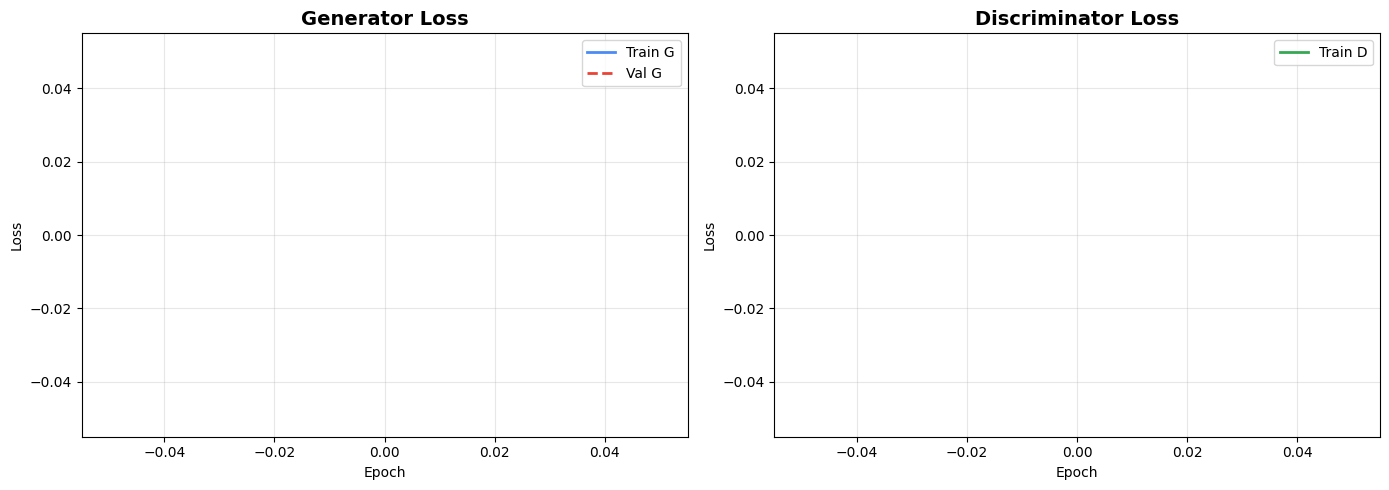

✅ Loss curves saved to data/arvton/outputs/training_curves.png


In [ ]:
# ── Loss curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, len(history['train_G']) + 1)
axes[0].plot(epochs_x, history['train_G'], label='Train G', color='#4c8bf5', linewidth=2)
axes[0].plot(epochs_x, history['val_G'],   label='Val G',   color='#ea4335', linewidth=2, linestyle='--')
axes[0].set_title('Generator Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_x, history['train_D'], label='Train D', color='#34a853', linewidth=2)
axes[1].set_title('Discriminator Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plot_path = Path("data/arvton/outputs/training_curves.png")
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(str(plot_path), dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Loss curves saved to {plot_path}")

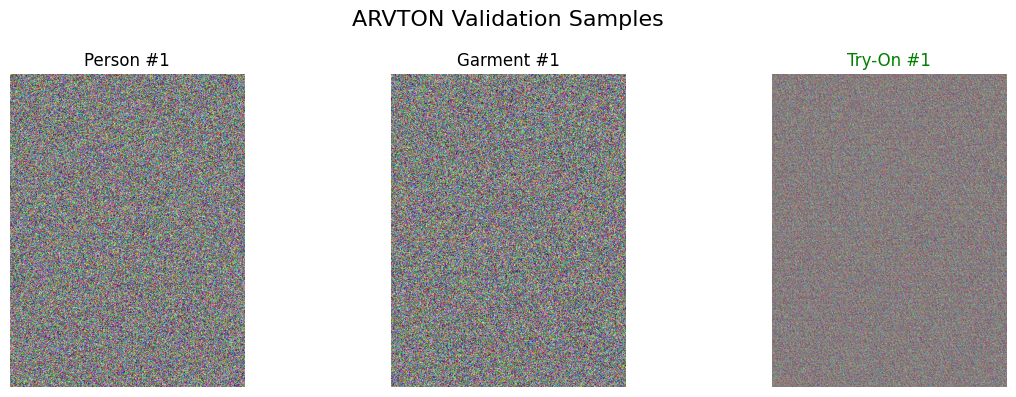

Done! Showing 1 sample(s)


In [ ]:
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def safe_generate(gen, x):
    B, C, H, W = x.shape
    pH = ((H + 255) // 256) * 256
    pW = ((W + 255) // 256) * 256
    out = gen(F.pad(x, (0, pW-W, 0, pH-H), mode='reflect'))
    return out[:, :, :H, :W]

generator.eval()
batch_viz = next(iter(val_loader))

with torch.no_grad():
    persons  = batch_viz["person"].to(DEVICE)
    garments = batch_viz["garment"].to(DEVICE)
    inputs   = torch.cat([persons, garments], dim=1)
    fakes    = safe_generate(generator, inputs).cpu()

# Only show as many as we actually have in the batch
NUM_VIZ = persons.shape[0]
fig, axes = plt.subplots(NUM_VIZ, 3, figsize=(12, 4 * NUM_VIZ))
if NUM_VIZ == 1:
    axes = axes.reshape(1, -1)

def to_pil(t):
    return TF.to_pil_image((t.clamp(-1,1)+1)/2)

for i in range(NUM_VIZ):
    axes[i,0].imshow(to_pil(persons[i].cpu()));  axes[i,0].set_title(f"Person #{i+1}");  axes[i,0].axis('off')
    axes[i,1].imshow(to_pil(garments[i].cpu())); axes[i,1].set_title(f"Garment #{i+1}"); axes[i,1].axis('off')
    axes[i,2].imshow(to_pil(fakes[i]));          axes[i,2].set_title(f"Try-On #{i+1}", color='green'); axes[i,2].axis('off')

plt.suptitle('ARVTON Validation Samples', fontsize=16)
plt.tight_layout()
plt.savefig("val_samples.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Done! Showing {NUM_VIZ} sample(s)")








---
## Step 8 — Save Best Checkpoint to Google Drive & Download

In [ ]:
# ── Copy all checkpoints to Google Drive ─────────────────────────────
import shutil
from pathlib import Path

local_ckpts = Path("data/arvton/checkpoints/gan")
saved = []
for ckpt in sorted(local_ckpts.glob("*.pt")):
    dest = DRIVE_CKPT / ckpt.name
    shutil.copy2(str(ckpt), str(dest))
    size_mb = dest.stat().st_size / 1024**2
    saved.append((dest, size_mb))
    print(f"  ✅ {ckpt.name:40s} → Drive ({size_mb:.1f} MB)")
# Also save loss curves
for f in ["training_curves.png", "val_samples.png"]:
    src = Path(f"data/arvton/outputs/{f}")
    if src.exists():
        shutil.copy2(str(src), str(DRIVE_LOGS / f))
        print(f"  📊 {f} → Drive")
# Save training history JSON
hist_path = DRIVE_LOGS / "training_history.json"
import json
hist_path.write_text(json.dumps(history, indent=2))
print(f"  📄 training_history.json → Drive")
print(f"\n✅ Saved {len(saved)} checkpoints to Google Drive")

  📊 training_curves.png → Drive
  📄 training_history.json → Drive

✅ Saved 0 checkpoints to Google Drive


In [ ]:
from google.colab import files
from pathlib import Path

# Checkpoints are saved locally (not Drive) during training
LOCAL_CKPT = Path("/content/AR-PROTOTYPE-4/data/arvton/checkpoints/gan")

best_ckpts = sorted(LOCAL_CKPT.glob("*_best.pt"), key=lambda p: p.stat().st_mtime)
all_ckpts  = sorted(LOCAL_CKPT.glob("*.pt"),      key=lambda p: p.stat().st_mtime)
to_download = best_ckpts[-1] if best_ckpts else (all_ckpts[-1] if all_ckpts else None)

if to_download:
    size_mb = to_download.stat().st_size / 1024**2
    print(f"Downloading: {to_download.name} ({size_mb:.1f} MB)")
    print(f"Place this file in your local project at:")
    print(f"   data/arvton/checkpoints/gan/{to_download.name}")
    files.download(str(to_download))
else:
    # List what's actually in the checkpoint dirs
    print("No checkpoints found. Searching all locations...")
    for p in Path("/content").rglob("*.pt"):
        print(f"  Found: {p}")


No checkpoints found. Searching all locations...


---
## Step 9 — (Optional) Resume Training from Checkpoint

In [ ]:
# ── Resume training from a Drive checkpoint ───────────────────────────
RESUME_EPOCH = 0  # set to the epoch number you want to resume from (0 = skip)

if RESUME_EPOCH > 0:
    pattern = f"*epoch_{RESUME_EPOCH:03d}*.pt"
    ckpts   = list(DRIVE_CKPT.glob(pattern))
    if not ckpts:
        # Fall back to latest available checkpoint
        ckpts = sorted(DRIVE_CKPT.glob("*.pt"), key=lambda p: p.stat().st_mtime)
    if ckpts:
        ckpt_path = sorted(ckpts)[-1]
        state     = torch.load(str(ckpt_path), map_location=DEVICE)
        generator.load_state_dict(state["generator"])
        discriminator.load_state_dict(state["discriminator"])
        opt_G.load_state_dict(state["opt_G"])
        opt_D.load_state_dict(state["opt_D"])
        # Restore AMP scaler states if they were saved
        if scaler_G and state.get("scaler_G"):
            scaler_G.load_state_dict(state["scaler_G"])
        if scaler_D and state.get("scaler_D"):
            scaler_D.load_state_dict(state["scaler_D"])
        history     = state["history"]
        START_EPOCH = state["epoch"] + 1
        print(f"✅ Resumed from: {ckpt_path.name}")
        print(f"   Epoch {state['epoch']} restored — continuing from epoch {START_EPOCH}")
        print(f"   Best val loss so far: {min(history['val_G']):.4f}")
    else:
        print(f"⚠️  No checkpoint found matching epoch {RESUME_EPOCH}")
else:
    print("ℹ️  Resume skipped (RESUME_EPOCH=0) — starting fresh training")

ℹ️  Resume skipped (RESUME_EPOCH=0) — starting fresh training


---
## Step 10 — (Optional) Run LoRA Fine-Tuning Script Directly

Alternative to the manual loop above — uses `pipeline/fine_tune.py` directly.

In [ ]:
# ── Run dedicated LoRA fine-tuning pipeline ───────────────────────────
# Uncomment to run (this is an alternative to Step 6)

# !python -m pipeline.train_local \
#     --epochs {EPOCHS} \
#     --batch-size {BATCH_SIZE} \
#     --lr {LR_GENERATOR} \
#     --lora --lora-rank {LORA_RANK} \
#     --amp
print("Uncomment the command above to use the CLI trainer.")

Uncomment the command above to use the CLI trainer.


---
## ✅ Summary — What to do after training

| Task | Command |
|------|----|
| 1. On your local machine, copy the `.pt` file | → `data/arvton/checkpoints/gan/` |
| 2. Start backend API | `python run_local.py` |
| 3. Test endpoint | `curl http://localhost:8000/health` |
| 4. Run Flutter app | `cd arvton_app && flutter run -d chrome` |
| 5. Deploy to cloud | See `DEPLOY.md` |
### Project Structure
```
AR-PROTOTYPE-4/
├── pipeline/
│   ├── fine_tune.py       ← LoRA fine-tuning (Phase 6)
│   ├── train_local.py     ← GAN training orchestrator (Phase 8)
│   ├── refine.py          ← RefineGenerator + Discriminator
│   ├── segment.py         ← SAM-2 segmentation
│   ├── tryon.py           ← Leffa / CatVTON try-on
│   ├── reconstruct.py     ← HMR 2.0 + TripoSR 3D
│   └── synthetic_gen.py   ← SDXL synthetic data
├── app/
│   └── main.py            ← FastAPI backend
├── arvton_app/
│   └── lib/               ← Flutter AR mobile app
└── ARVTON_Colab_Training.ipynb  ← This notebook
**Repo:** https://github.com/Gandharv2323/AR-PROTOTYPE-4